In [1]:
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm

font_paths = [
    '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',      # 文泉驿微米黑
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc', # Noto字体
    '/usr/share/fonts/adobe-source-han-sans/SourceHanSansCN-Regular.otf', # 思源黑体
    os.path.expanduser('~/.fonts/SourceHanSansSC-Regular.otf') # 用户目录字体
]
for path in font_paths:
    if os.path.exists(path):
        font_name = fm.FontProperties(fname=path).get_name()
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [font_name]
        print(f"使用字体文件: {path} -> {font_name}")
        break

使用字体文件: /usr/share/fonts/truetype/wqy/wqy-microhei.ttc -> WenQuanYi Micro Hei


使用设备: cuda
Epoch [1/10], Loss: 0.295829
Epoch [2/10], Loss: 0.211330
Epoch [3/10], Loss: 0.161311
Epoch [4/10], Loss: 0.148443
Epoch [5/10], Loss: 0.139048
Epoch [6/10], Loss: 0.132425
Epoch [7/10], Loss: 0.127942
Epoch [8/10], Loss: 0.124042
Epoch [9/10], Loss: 0.120222
Epoch [10/10], Loss: 0.117257


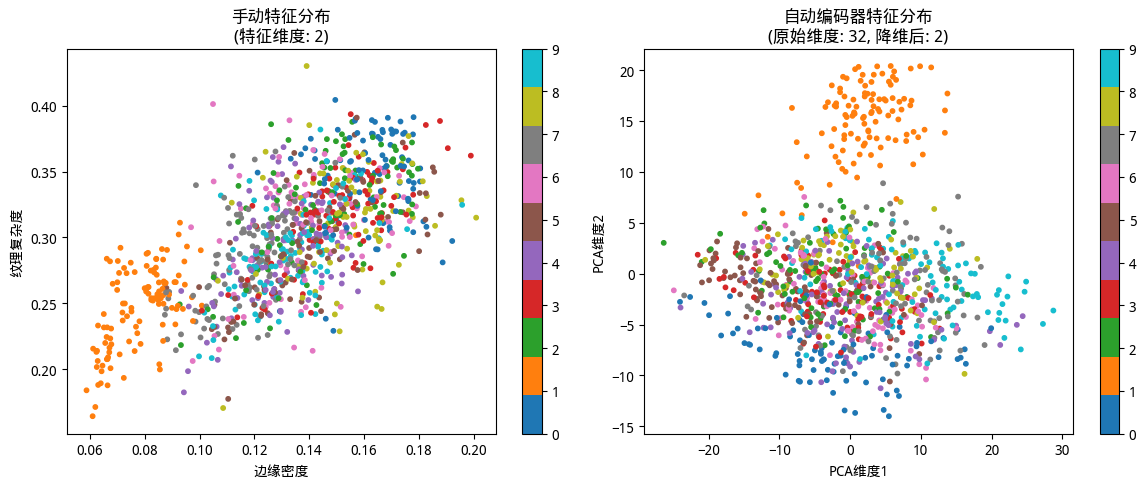

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

# 1. 手动特征提取函数（与原逻辑一致，适配PyTorch Tensor）
def manual_features(images):
    """提取图像的边缘密度和纹理复杂度"""
    features = []
    for img in images:
        # 确保图像是2D（处理PyTorch Tensor或NumPy数组）
        img_np = img.cpu().numpy() if isinstance(img, torch.Tensor) else img
        if img_np.ndim == 1:
            img_np = img_np.reshape(28, 28)
        # 计算边缘密度：行差分均值 + 列差分均值
        edge_density = np.mean(np.abs(np.diff(img_np, axis=0))) + np.mean(np.abs(np.diff(img_np, axis=1)))
        # 计算纹理复杂度：图像像素标准差
        texture_complexity = np.std(img_np)
        features.append([edge_density, texture_complexity])
    return np.array(features)

# 2. PyTorch自动编码器模型定义
class Autoencoder(nn.Module):
    def __init__(self, feature_dim=32):
        super(Autoencoder, self).__init__()
        # 编码器：784 -> 128 -> 64 -> feature_dim
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, feature_dim),
            nn.ReLU()  # 编码器输出特征
        )
        # 解码器：feature_dim -> 64 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()  # 输出归一化到[0,1]，与输入匹配
        )
    
    def forward(self, x):
        """完整前向传播：编码+解码"""
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        """仅编码，用于特征提取"""
        return self.encoder(x)

# 3. 特征比较与可视化函数（与原逻辑一致）
def compare_features(manual_feats, auto_feats, labels):
    """比较手动特征和自动特征的效果"""
    plt.figure(figsize=(12, 5))
    
    # 绘制手动特征散点图
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(manual_feats[:, 0], manual_feats[:, 1], c=labels, cmap='tab10', s=10)
    plt.colorbar(scatter, ticks=range(10))
    plt.title('手动特征分布\n(特征维度: 2)')
    plt.xlabel('边缘密度')
    plt.ylabel('纹理复杂度')
    
    # 自动特征通过PCA降维到2D后绘制
    plt.subplot(1, 2, 2)
    pca = PCA(n_components=2)
    auto_2d = pca.fit_transform(auto_feats)
    scatter = plt.scatter(auto_2d[:, 0], auto_2d[:, 1], c=labels, cmap='tab10', s=10)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(f'自动编码器特征分布\n(原始维度: {auto_feats.shape[1]}, 降维后: 2)')
    plt.xlabel('PCA维度1')
    plt.ylabel('PCA维度2')
    
    plt.tight_layout()
    plt.show()

# 主程序
if __name__ == "__main__":
    # 设备配置：优先使用GPU，否则CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")
    
    # 1. 数据加载与预处理（PyTorch方式）
    transform = transforms.Compose([
        transforms.ToTensor(),  # 转换为Tensor并归一化到[0,1]
        transforms.Lambda(lambda x: x.view(-1))  # 展平为784维向量
    ])
    
    # 加载MNIST训练集
    train_dataset = datasets.MNIST(root='../DL/data', train=True, transform=transform, download=True)
    
    # 取前1000个样本用于演示
    n_samples = 1000
    x_subset = torch.stack([train_dataset[i][0] for i in range(n_samples)]).to(device)
    y_subset = np.array([train_dataset[i][1] for i in range(n_samples)])
    
    # 2. 提取手动特征
    manual_feats = manual_features(x_subset)
    
    # 3. 训练自动编码器
    # 超参数
    feature_dim = 32
    batch_size = 256
    epochs = 10
    learning_rate = 1e-3
    
    # 初始化模型、损失函数和优化器
    model = Autoencoder(feature_dim=feature_dim).to(device)
    criterion = nn.BCELoss()  # 二分类交叉熵，适合0-1归一化的输入
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 准备完整训练集的数据加载器（用于训练自编码器）
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # 训练循环
    model.train()  # 切换到训练模式
    for epoch in range(epochs):
        running_loss = 0.0
        for data, _ in train_loader:
            data = data.to(device)  # 输入数据
            target = data  # 自编码器的目标是重构输入
            
            # 前向传播
            outputs = model(data)
            loss = criterion(outputs, target)
            
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * data.size(0)
        
        # 计算epoch平均损失
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}')
    
    # 4. 提取自动编码器特征
    model.eval()  # 切换到评估模式
    with torch.no_grad():  # 禁用梯度计算，节省内存
        auto_feats = model.encode(x_subset).cpu().numpy()  # 编码并转换为NumPy数组
    
    # 5. 可视化对比两种特征
    compare_features(manual_feats, auto_feats, y_subset)
